In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import seaborn as sns

In [2]:
data = {
"income": [20000,22000,25000,27000,30000,32000,35000,37000,40000,42000,
           45000,47000,50000,52000,55000,57000,60000,62000,65000,67000,
           70000,72000,75000,77000,80000,82000,85000,87000,90000,92000,
           95000,97000,100000,102000,105000,107000,110000,112000,115000,117000,
           120000,122000,125000,127000,130000,132000,135000,137000,140000,142000,
           145000,147000,150000,152000,155000,157000,160000,162000,165000,167000,
           170000,172000,175000,177000,180000,182000,185000,187000,190000,192000,
           195000,197000,200000,202000,205000,207000,210000,212000,215000,217000,
           220000,222000,225000,227000,230000,232000,235000,237000,240000,242000,
           245000,247000,250000,252000,255000,257000,260000,262000,265000,270000],

"credit_score": [500,520,540,560,580,600,620,640,660,680,
                 700,720,740,760,780,800,820,840,860,880,
                 600,620,640,660,680,700,720,740,760,780,
                 800,820,840,860,880,600,620,640,660,680,
                 700,720,740,760,780,800,820,840,860,880,
                 600,620,640,660,680,700,720,740,760,780,
                 800,820,840,860,880,600,620,640,660,680,
                 700,720,740,760,780,800,820,840,860,880,
                 600,620,640,660,680,700,720,740,760,780,
                 800,820,840,860,880,700,720,740,760,780],

"loan_amount": [50000,52000,54000,56000,58000,60000,62000,64000,66000,68000,
                70000,72000,74000,76000,78000,80000,82000,84000,86000,88000,
                90000,92000,94000,96000,98000,100000,102000,104000,106000,108000,
                110000,112000,114000,116000,118000,120000,122000,124000,126000,128000,
                130000,132000,134000,136000,138000,140000,142000,144000,146000,148000,
                150000,152000,154000,156000,158000,160000,162000,164000,166000,168000,
                170000,172000,174000,176000,178000,180000,182000,184000,186000,188000,
                190000,192000,194000,196000,198000,200000,202000,204000,206000,208000,
                210000,212000,214000,216000,218000,220000,222000,224000,226000,228000,
                230000,232000,234000,236000,238000,240000,242000,244000,246000,250000],

"loan_approved": [0,0,0,0,0,0,0,0,0,0,
                  0,0,1,1,1,1,1,1,1,1,
                  0,0,0,0,0,1,1,1,1,1,
                  1,1,1,1,1,0,0,0,0,1,
                  1,1,1,1,1,1,1,1,1,1,
                  0,0,0,0,1,1,1,1,1,1,
                  1,1,1,1,1,0,0,0,0,1,
                  1,1,1,1,1,1,1,1,1,1,
                  0,0,0,0,1,1,1,1,1,1,
                  1,1,1,1,1,1,1,1,1,1]
}

In [3]:
df=pd.DataFrame(data)

In [4]:
X=df.drop("loan_approved",axis=1)
y=df["loan_approved"]

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [6]:
scaler=StandardScaler()

In [7]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [8]:
model=SVC()

In [9]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto", 0.01, 0.001],
}

In [10]:
cv=GridSearchCV(model,param_grid=param_grid,scoring="accuracy",cv=5)
cv.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

In [11]:
print(cv.best_params_)
print(cv.best_score_)

{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
0.9733333333333334


In [12]:
pre=cv.predict(X_test)

In [13]:
pre

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1])

In [14]:
print(accuracy_score(y_test,pre))

0.96


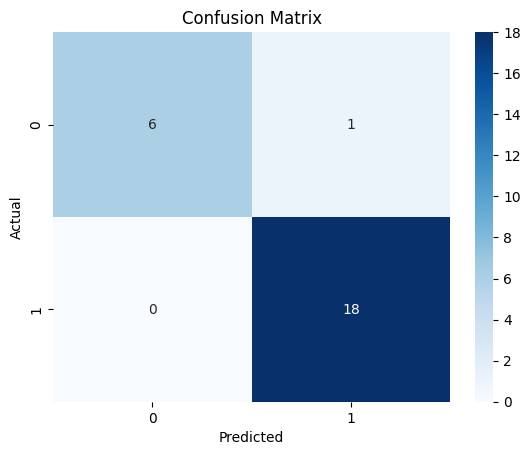

In [15]:
cm = confusion_matrix(y_test, pre)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [16]:
print(classification_report(y_test,pre))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.95      1.00      0.97        18

    accuracy                           0.96        25
   macro avg       0.97      0.93      0.95        25
weighted avg       0.96      0.96      0.96        25

